# Opdracht - 


## Inlezen van de variabelen - creëren van de omgeving

In [79]:
import os
import json
import sys
import pandas as pd
from datetime import date, datetime
import calendar
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update({
    "figure.facecolor":    "white",
    "axes.facecolor":      "#F8F9FA",
    "axes.grid":           True,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.titlesize":      14,
    "axes.titleweight":    "bold",
    "axes.labelsize":      13,
    "axes.labelcolor":     "#333333",
    "xtick.labelsize":     12,
    "ytick.labelsize":     12,
    "xtick.color":         "#555555",
    "ytick.color":         "#555555",
    "grid.color":          "white",
    "grid.linewidth":      1.2,
    "lines.linewidth":     1.5,
    "legend.fontsize":     10,
    "font.family":         "Arial"
})

os.chdir(r"C:\Users\kurtm\Documents\Oefening01.01")



# Lees de configuratie in
config = load_project_config(r"./config.json")

kleuren = config["Plot"]["kleuren"]


## Main programma - lees de broninformatie in

In [5]:



#Overloop alle files in de Source directory
SourceDir = os.path.join(config["Directories"]["Root"],config["Directories"]["Data"],config["Directories"]["Input"])

df_births = pd.DataFrame()

for ReadFile in os.listdir(SourceDir):
    # lees de file in
    if  not ReadFile.endswith('.csv'):
        continue
    EchteGeboortedag = os.path.splitext(ReadFile)[0] 
    #bepaal of geldige datum in filenaam - check dan in de config wat je moet doen
    if not is_geldige_datum(EchteGeboortedag):
        functie_naam = config["Decisions"]["Wrong Date"]
        if not functie_naam in globals() or callable(globals()[functie_naam]):
            continue
        EchteGeboortedag = globals()[functie_naam](EchteGeboortedag)


    df_File = pd.read_csv(os.path.join(SourceDir,ReadFile))
    df_File['verwachte datum'] = pd.to_datetime(df_File['verwachte datum'])
    df_File["date"] = pd.to_datetime(EchteGeboortedag)
    df_File["SourceFile"] = ReadFile
    df_births = pd.concat([df_births, df_File], ignore_index=True)

df_births = df_births.sort_values('date')
df_births["dag van het jaar"] = df_births["date"].dt.dayofyear
df_births["dag van de week"] = df_births["date"].dt.dayofweek
df_births.to_excel(os.path.join(config["Directories"]["Root"],config["Directories"]["Data"],config["Directories"]["Temp"],config["Files"]["RestFile"]), index=False)


# Main programma - voer oefeningen uit

## Stap 1: data inlezen (1 pnt)

Bouw één DataFrame `df_births` met alle geboortes uit de map `data/geboortes`.

**Output**
- `df_births` bevat alle rijen uit alle CSV-bestanden.
- `df_births` bevat een kolom `date` als echte datetime (`YYYY-MM-DD`), afgeleid uit de bestandsnaam.
- `df_births` bevat een kolom `dag_van_jaar` met waarden van 1 tot 365.
- De observatie-grain is identiek aan de bron: **1 rij = 1 geboorte**.

**Te tonen checks**
- Aantal rijen in `df_births`
- Minimum- en maximumdatum
- Minimum en maximum van `day_of_year`
- Geen onbestaande datums (bv. dag 0, dag 32, 29/2 in niet-schrikkeljaren, geboortejaar 2027,...)

In [6]:
df_births.dtypes

gemeente                       str
naam                           str
geslacht                       str
verwachte datum     datetime64[us]
date                datetime64[us]
SourceFile                     str
dag van het jaar             int32
dag van de week              int32
dtype: object

In [7]:
len(df_births)

116850

In [ ]:
df_births["date"].min()

Timestamp('2019-12-31 00:00:00')

In [14]:
df_births["date"].max()

Timestamp('2019-12-31 00:00:00')

In [16]:
df_births["dag van het jaar"].min()

np.int32(1)

In [17]:
df_births["dag van het jaar"].max()

np.int32(365)

# geen onbestaande datums
Werd opgelost et een functie die in de config werd vermeld
1. eerstvolgende
2. Vorige
3. ignore als geen geldige functie

## Stap 2: EDA

### Vraag 1: Initial Plot

Maak een plot van het aantal geboortes per dag van het jaar. Gebruik een horizontale rode stippellijn om het gemiddelde aan te geven. (1 pnt)

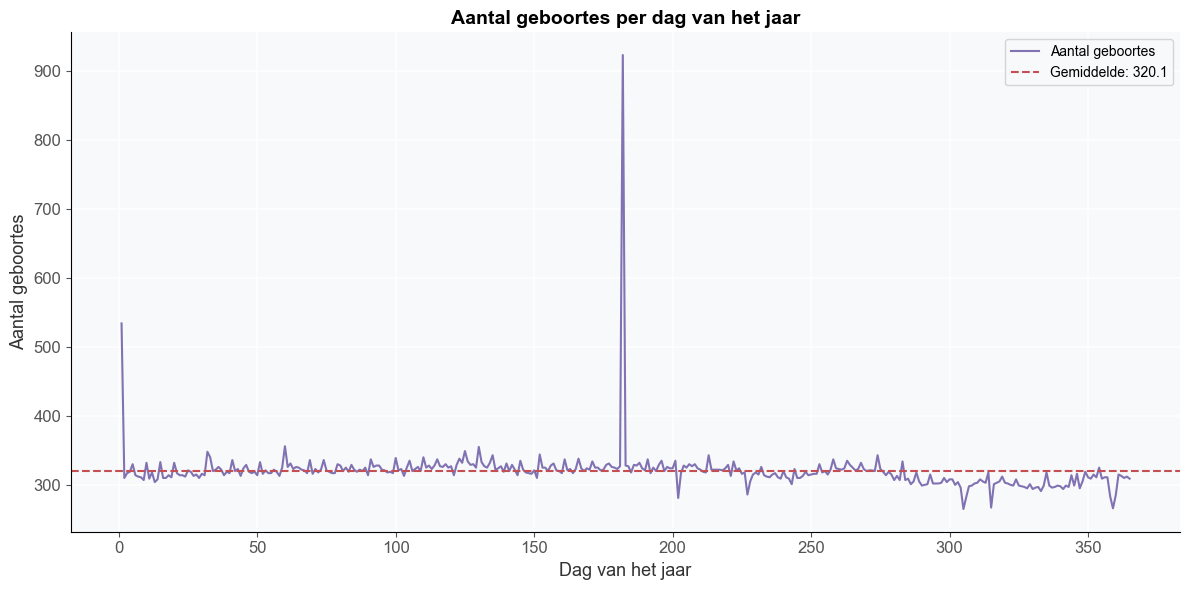

In [ ]:


geboortes_per_dag = df_births.groupby("dag van het jaar").size().reset_index(name="aantal_geboortes")
gemiddelde = geboortes_per_dag["aantal_geboortes"].mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    geboortes_per_dag["dag van het jaar"],
    geboortes_per_dag["aantal_geboortes"],
    color=kleuren["paars"],
    label="Aantal geboortes"
)
ax.axhline(
    gemiddelde,
    color=kleuren["rood"],
    linestyle="--",
    label=f"Gemiddelde: {gemiddelde:.1f}"
)
ax.set_title("Aantal geboortes per dag van het jaar")
ax.set_xlabel("Dag van het jaar")
ax.set_ylabel("Aantal geboortes")
ax.legend()
plt.tight_layout()
plt.show()

### Vraag 2: Outliers vinden & behandelen
#### Vraag 2.1 Zoek alle outliers in de dataset. (1 pnt)

Kies een regel om een datapunt als 'outlier' te classifieren, pas deze toe en verdedig je keuze.

In [ ]:
maximum = geboortes_per_dag["aantal_geboortes"].max()
minimum = geboortes_per_dag["aantal_geboortes"].min()



x = 70     # t.o.v. het gemiddelde


# bepaal de ondergrens voor de maxima
MaxLow = int(maximum - ((maximum - gemiddelde) *x/100))

# bepaal de bovengrens voor de minima
MinHigh = int(minimum + ((gemiddelde - minimum) *x/100))

df_MaxOutlier = geboortes_per_dag.loc[geboortes_per_dag["aantal_geboortes"] > MaxLow]
df_MinOutlier = geboortes_per_dag.loc[geboortes_per_dag["aantal_geboortes"] < MinHigh]
display(df_MaxOutlier)
display(df_MinOutlier)

#### Vraag 2.2 Outlier remediation (1 pnt)
Je stelt vast dat twee dagen eruit springen als outliers. Corrigeer en voeg foute rijen toe aan `df_wrong` met een duidelijk omschreven reden. Documenteer in een comment welk patroon je opmerkte en  verdedig je correctiestrategie. Hermaak ten slotte de figuur uit Vraag 1 op basis van `df_births_clean`.

Er zijn 2 dagen die er aan de bovenkant uitschieten. De entries van deze 2 dagen zullen eruit gehaald worden

In [16]:
outlier_dagen = df_MaxOutlier["dag van het jaar"].tolist()

# Masker: rijen waarvan de dag van het jaar een outlier is
masker_wrong = df_births["dag van het jaar"].isin(outlier_dagen)

# df_wrong: de foutieve rijen met uitleg
df_wrong = df_births[masker_wrong].copy()
df_wrong["reden"] = df_wrong["dag van het jaar"].map({
    1:   "Dag 1 (1 jan): 534 geboortes — uitschieter hoog (feestdageffect?)",
    182: "Dag 182 (1 jul): 923 geboortes — extreme uitschieter, ~3× normaal",
})

# df_births_clean: alles zonder de outlier-dagen
df_births_clean = df_births[~masker_wrong].reset_index(drop=True)

print(f"Rijen verwijderd : {masker_wrong.sum()}")
print(f"Rijen in clean   : {len(df_births_clean)}")


Rijen verwijderd : 1457
Rijen in clean   : 115393


In [25]:
df_wrong

,gemeente,naam,geslacht,verwachte datum,date,SourceFile,dag van het jaar,dag van de week,reden
0,Hooglede,Elias,Mannelijk,2019-01-14,2019-01-01,2019-1-1.csv,1,1,Dag 1 (1 jan): 534 geboortes — uitschieter hoo...
364,Scherpenheuvel-Zichem,Rudolphe,Mannelijk,2019-01-11,2019-01-01,2019-1-1.csv,1,1,Dag 1 (1 jan): 534 geboortes — uitschieter hoo...
363,Courcelles,Sarah,Vrouwelijk,2019-01-02,2019-01-01,2019-1-1.csv,1,1,Dag 1 (1 jan): 534 geboortes — uitschieter hoo...
362,Lille,Maria,Vrouwelijk,2018-12-31,2019-01-01,2019-1-1.csv,1,1,Dag 1 (1 jan): 534 geboortes — uitschieter hoo...
361,Koksijde,Martine,Vrouwelijk,2018-12-29,2019-01-01,2019-1-1.csv,1,1,Dag 1 (1 jan): 534 geboortes — uitschieter hoo...
...,...,...,...,...,...,...,...,...,...
87350,Aalst (Aalst),Paula,Vrouwelijk,2019-07-15,2019-07-01,2019-7-1.csv,182,0,Dag 182 (1 jul): 923 geboortes — extreme uitsc...
87349,Rotselaar,Johan,Mannelijk,2019-07-08,2019-07-01,2019-7-1.csv,182,0,Dag 182 (1 jul): 923 geboortes — extreme uitsc...
87348,Anderlecht,Jawad,Mannelijk,2019-07-24,2019-07-01,2019-7-1.csv,182,0,Dag 182 (1 jul): 923 geboortes — extreme uitsc...
87346,Borgworm,Daniel,Mannelijk,2019-07-03,2019-07-01,2019-7-1.csv,182,0,Dag 182 (1 jul): 923 geboortes — extreme uitsc...


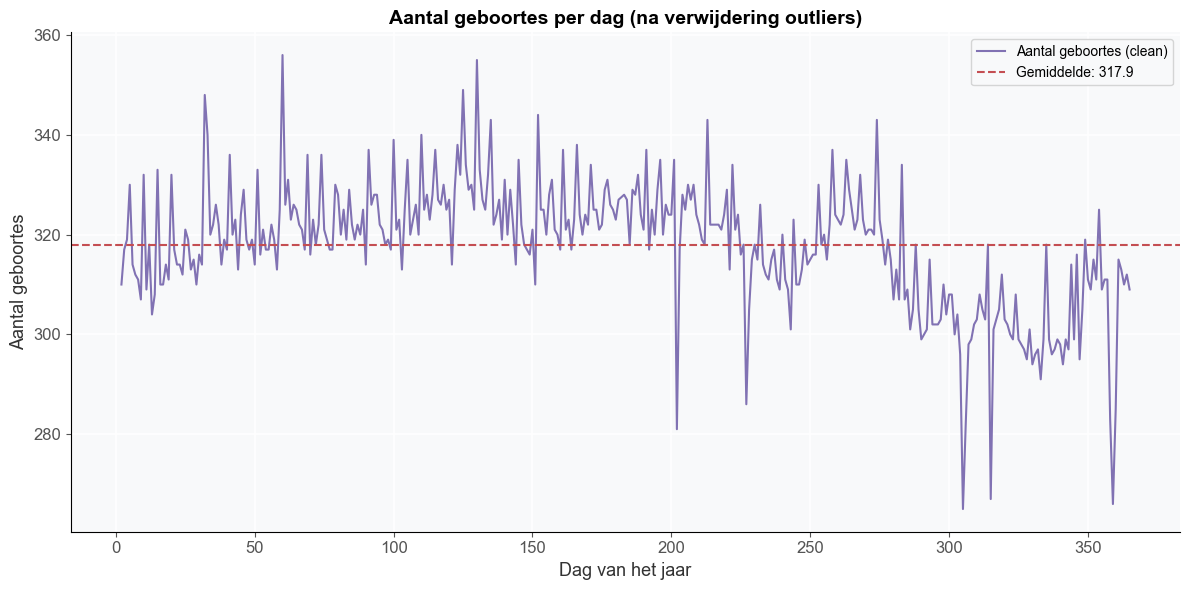

In [33]:
#Hermaak de figuur op basis van df_births_clean

outlier_dagenkleuren = config["Plot"]["kleuren"]

geboortes_clean = (
    df_births_clean
    .groupby(["dag van het jaar", "date"])
    .size()
    .reset_index(name="aantal_geboortes")
)
gemiddelde_clean = geboortes_clean["aantal_geboortes"].mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    geboortes_clean["dag van het jaar"],
    geboortes_clean["aantal_geboortes"],
    color=kleuren["paars"],
    label="Aantal geboortes (clean)",
)
ax.axhline(
    gemiddelde_clean,
    color=kleuren["rood"],
    linestyle="--",
    label=f"Gemiddelde: {gemiddelde_clean:.1f}",
)
ax.set_title("Aantal geboortes per dag (na verwijdering outliers)")
ax.set_xlabel("Dag van het jaar")
ax.set_ylabel("Aantal geboortes")
ax.legend()
plt.tight_layout()
plt.show()

In [42]:
#Stap 1 — Filter op de tweede helft van het jaar (dag 183–365)
geboortes_h2 = geboortes_clean[
    geboortes_clean["dag van het jaar"] >= 183
].copy()

#Stap 2 — Bereken de afwijking t.o.v. het gemiddelde (abs)
gemiddelde_h2 = geboortes_h2["aantal_geboortes"].mean()

geboortes_h2["afwijking"] = (
    geboortes_h2["aantal_geboortes"] - gemiddelde_h2
).abs()

# Selecteer de 8 meest extreme dagen
top8_extreme = (
    geboortes_h2
    .nlargest(8, "afwijking")
    .sort_values("date")
    [["dag van het jaar", "aantal_geboortes", "afwijking", "date"]]
)

display(top8_extreme)

,dag van het jaar,aantal_geboortes,afwijking,date
199,202,281,31.404372,2019-07-21
210,213,343,30.595628,2019-08-01
271,274,343,30.595628,2019-10-01
302,305,265,47.404372,2019-11-01
303,306,282,30.404372,2019-11-02
312,315,267,45.404372,2019-11-11
355,358,283,29.404372,2019-12-24
356,359,266,46.404372,2019-12-25


In [48]:
geboortes_clean[geboortes_clean["date"].dt.date == pd.Timestamp("2019-08-15").date()]

,dag van het jaar,date,aantal_geboortes
224,227,2019-08-15,286


### Vraag 3: Verbanden per week/maand

#### Vraag 3.1 (2 pnt)
We zien vele pieken en dalen in de evolutie van het aantal geboortes. We willen deze grafiek graag iets "gladder" maken. Kan je hiervoor eens een visualizatie maken van het **gemiddeld** aantal geboortes per week (dit voor elke week, dus maandag-maandag, dinsdag-dinsdag, woensdag-woensdag, ...).

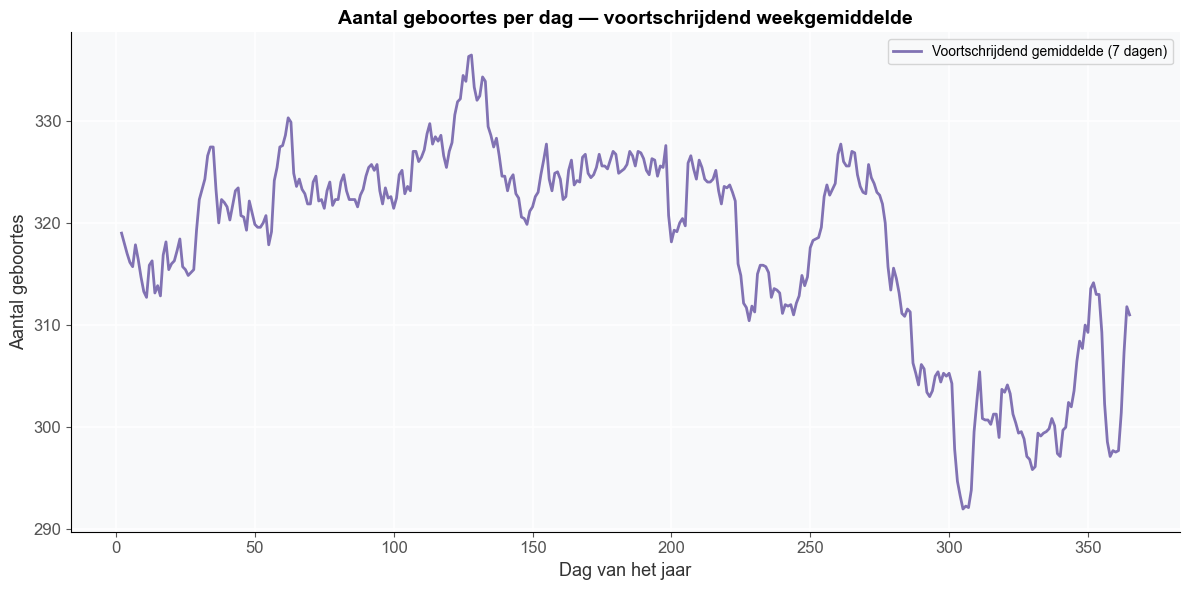

In [59]:
# "maandag-maandag, dinsdag-dinsdag, ..." betekent een voortschrijdend
# gemiddelde met venster = 7, gecentreerd op de dag zelf.
# center=True → 3 dagen voor + dag zelf + 3 dagen na.

geboortes_clean["gemiddelde_per_week"] = (
    geboortes_clean["aantal_geboortes"]
    .rolling(window=7, center=True, min_periods=1)
    .mean()
)



fig, ax = plt.subplots(figsize=(12, 6))



# Voortschrijdend weekgemiddelde
ax.plot(
    geboortes_clean["dag van het jaar"],
    geboortes_clean["gemiddelde_per_week"],
    color=kleuren["paars"],
    linewidth=2,
    label="Voortschrijdend gemiddelde (7 dagen)",
)



ax.set_title("Aantal geboortes per dag — voortschrijdend weekgemiddelde")
ax.set_xlabel("Dag van het jaar")
ax.set_ylabel("Aantal geboortes")
ax.legend()
plt.tight_layout()
plt.show()

#### Vraag 3.2 (2 pnt)
Dat ziet er al een stuk mooier uit!  We zien ook een aantal duidelijk dips & pieken verschijnen die we eerder niet zagen. We kunnen nu ook even kijken naar het gemiddeld aantal geboortes per dag van de week! Misschien worden er wel gewoon veel minder mensen geboren op zondag dan een andere dag?

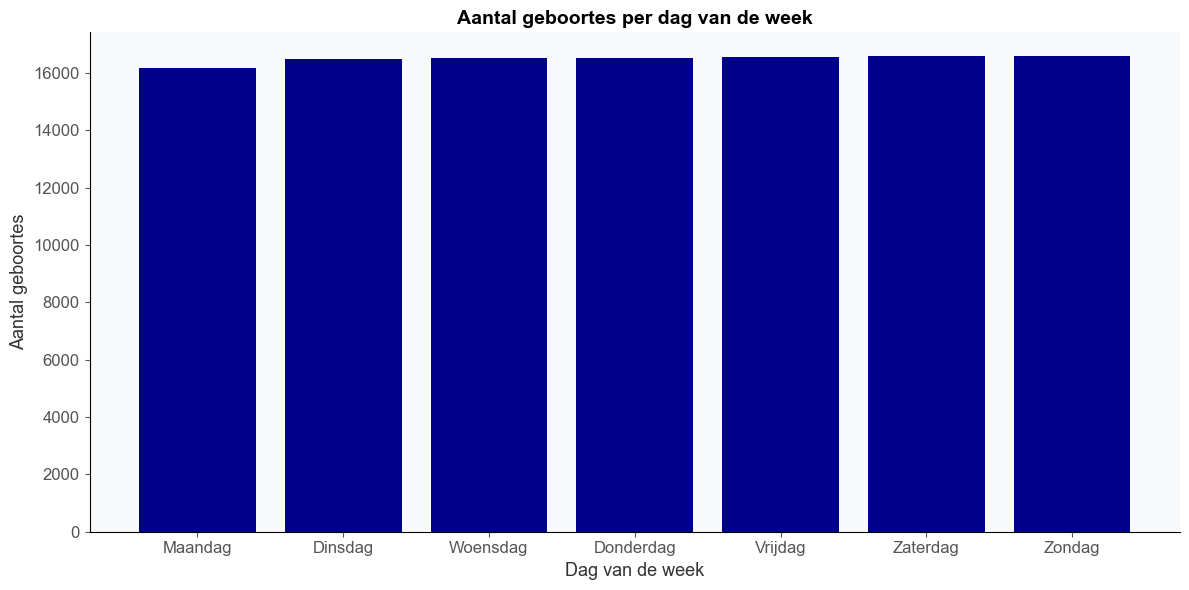

In [70]:
geboortes_per_weekdag = (
    df_births_clean
    .groupby("dag van de week")
    .size()
    .reset_index(name="aantal_geboortes")
)

dag_namen = ["Maandag", "Dinsdag", "Woensdag", "Donderdag", "Vrijdag", "Zaterdag", "Zondag"]
geboortes_per_weekdag["naam"] = geboortes_per_weekdag["dag van de week"].map(
    dict(enumerate(dag_namen))
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    geboortes_per_weekdag["naam"],
    geboortes_per_weekdag["aantal_geboortes"],
    color=kleuren["marineblauw"],
)

ax.set_title("Aantal geboortes per dag van de week")
ax.set_xlabel("Dag van de week")
ax.set_ylabel("Aantal geboortes")
ax.grid(False)
plt.tight_layout()
plt.show()

#### Vraag 3.3 — Maandverschillen in geboortes (3pnt)

Je beschikt over geboortecijfers per dag voor één kalenderjaar.

Maak één visualisatie die het gemiddeld aantal geboortes per maand toont
en tegelijk toelaat om de variatie binnen elke maand te vergelijken.

De visualisatie moet:
- de maanden tonen in chronologische volgorde (januari → december)
- per maand het gemiddelde aantal geboortes tonen (IK NEEM AAN GEMIDDELDE PER DAG)
- per maand de onzekerheid rond dat gemiddelde tonen op 95% betrouwbaarheid en gebaseerd op de dagwaarden (niet handmatig berekend)


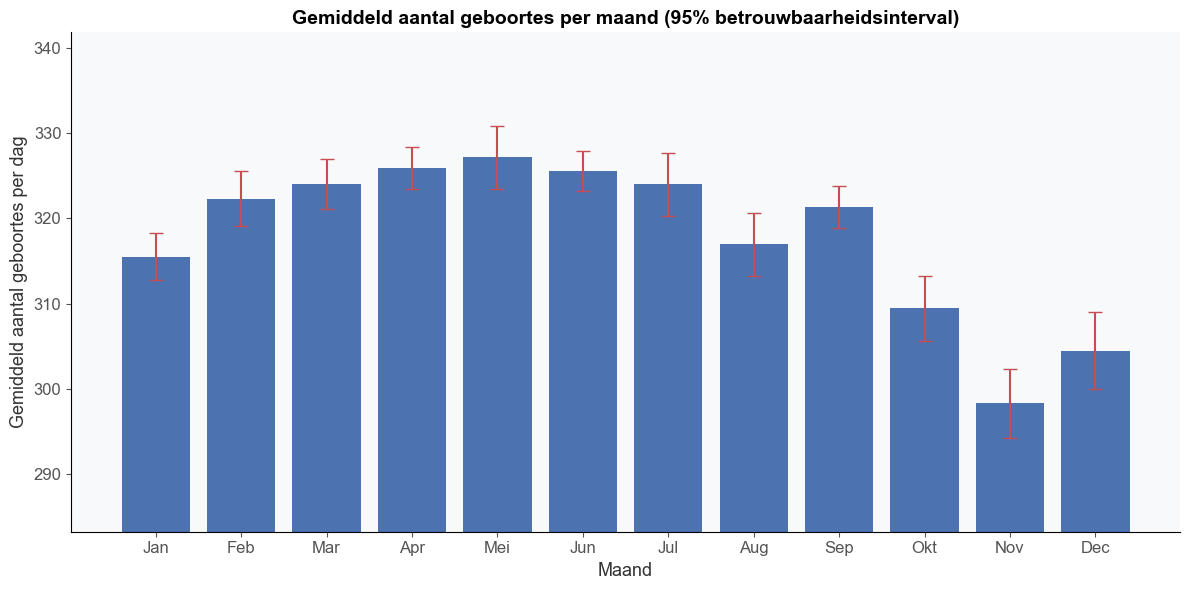

In [90]:
import numpy as np

# Voeg maandkolom toe op basis van de datum
df_births_clean["maand"] = df_births_clean["date"].dt.month

maand_namen = ["Jan", "Feb", "Mar", "Apr", "Mei", "Jun",
               "Jul", "Aug", "Sep", "Okt", "Nov", "Dec"]

# Stap 1: tel geboortes per dag én per maand
# → dagwaarden per maand als basis voor het BI
geboortes_per_dag_maand = (
    df_births_clean
    .groupby(["maand", "date"])
    .size()
    .reset_index(name="aantal_geboortes")
)

# Stap 2: bereken gemiddelde + 95% BI per maand
maand_stats = (
    geboortes_per_dag_maand
    .groupby("maand")["aantal_geboortes"]
    .apply(ci95)
    .unstack()
    .reset_index()
)

# Stap 3: plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    maand_namen,
    maand_stats["gemiddelde"],
    color=kleuren["primair"],
    zorder=2,
)

ax.errorbar(
    maand_namen,
    maand_stats["gemiddelde"],
    yerr=[
        maand_stats["gemiddelde"] - maand_stats["ci_laag"],
        maand_stats["ci_hoog"]    - maand_stats["gemiddelde"],
    ],
    fmt="none",
    color=kleuren["rood"],
    capsize=5,
    linewidth=1.5,
    zorder=3,
)

# Y-as beginnen net onder minimum zodat verschillen zichtbaar zijn
y_min = maand_stats["ci_laag"].min()
y_max = maand_stats["ci_hoog"].max()
marge = (y_max - y_min) * 0.3
ax.set_ylim(y_min - marge, y_max + marge)

ax.set_title("Gemiddeld aantal geboortes per maand (95% betrouwbaarheidsinterval)")
ax.set_xlabel("Maand")
ax.set_ylabel("Gemiddeld aantal geboortes per dag")
ax.grid(False)
plt.tight_layout()
plt.show()

Het zijn twee geneste functies — van binnen naar buiten:
1. np.random.standard_t(df=n-1, size=100_000)
Trek 100.000 willekeurige getallen uit een t-verdeling met n-1 vrijheidsgraden. Voor januari (n=31) is dat dus een t-verdeling met 30 vrijheidsgraden. Je krijgt een reeks van 100.000 waarden terug.
2. np.percentile(..., [2.5, 97.5])
Sorteer die 100.000 waarden en neem:

het 2.5e percentiel → de waarde waarbij 2.5% van de trekkingen lager ligt
het 97.5e percentiel → de waarde waarbij 97.5% van de trekkingen lager ligt

Het stuk daartussenin omvat dus 95% van alle waarden — dat zijn de grenzen van het 95% betrouwbaarheidsinterval.
Visueel:
|--2.5%--|--------95%--------|--2.5%--|
        t[0]               t[1]
       (~-2.04)           (~+2.04)
t is dus een lijst van twee waarden: [t[0], t[1]], de linker- en rechtergrens van de t-verdeling.

In [88]:
print(maand_stats.head())

   maand     level_1  aantal_geboortes
0      1  gemiddelde        315.533333
1      1     ci_laag        312.727349
2      1     ci_hoog        318.342243
3      2  gemiddelde        322.321429
4      2     ci_laag        319.089550


# Functies

In [89]:
def ci95(x):
    """
    Berekent het gemiddelde en 95% betrouwbaarheidsinterval
    op basis van de t-verdeling, zonder scipy.
    """
    n   = len(x)
    gem = x.mean()

    # Standaardfout van het gemiddelde: s / √n
    se = x.std(ddof=1) / n**0.5

    # t-kritische waarde via Monte Carlo:
    # trek 100.000 waarden uit t-verdeling met n-1 vrijheidsgraden
    # → 2.5e en 97.5e percentiel geven de grenzen van het 95% BI
    t = np.percentile(
        np.random.standard_t(df=n - 1, size=100_000), [2.5, 97.5]
    )

    # BI = gemiddelde ± t * se
    # t[0] negatief → ondergrens, t[1] positief → bovengrens
    return pd.Series({
        "gemiddelde": gem,
        "ci_laag":    gem + t[0] * se,
        "ci_hoog":    gem + t[1] * se,
    })

In [3]:
def is_geldige_datum(datum: str) -> bool:
    try:
        datetime.strptime(datum, '%Y-%m-%d')
        return True
    except ValueError:
        return False

def volgende_geldige_datum(datum: str) -> str:
    jaar, maand, dag = map(int, datum.split('-'))
    try:
        return date(jaar, maand, dag).strftime('%Y-%m-%d')
    except ValueError:
        if maand == 12:
            maand = 1
            jaar += 1
        else:
            maand += 1
        return date(jaar, maand, 1).strftime('%Y-%m-%d')

def laatste_geldige_datum(datum: str) -> str:
    jaar, maand, dag = map(int, datum.split('-'))
    laatste_dag = calendar.monthrange(jaar, maand)[1]
    geldige_dag = min(dag, laatste_dag)
    return date(jaar, maand, geldige_dag).strftime('%Y-%m-%d')

In [2]:
# inlezen configfile

def load_project_config(config_path):
    """
    Laadt de project-configuratie uit een JSON-bestand.
    Stopt het programma met een duidelijke foutmelding als er iets mis is.
    
    Returns:
        dict: de geladen configuratie
        
    Exits:
        sys.exit(1) bij file not found
        sys.exit(2) bij ongeldige JSON
        sys.exit(3) bij onverwachte andere fouten
    """
    # Zorg dat we een absoluut pad hebben (veiliger in notebooks/scripts)
    config_file = os.path.abspath(config_path)

    # 1. Bestaat het bestand überhaupt?
    if not os.path.isfile(config_file):
        print("FOUT: Configuratiebestand niet gevonden", file=sys.stderr)
        print(f"   Pad: {config_file}", file=sys.stderr)
        print("   Verwacht: JSON-bestand met 'directories' sleutel", file=sys.stderr)
        sys.exit(1)

    # 2. Proberen in te lezen
    try:
        with open(config_file, "r", encoding="utf-8") as f:
            config = json.load(f)

    except json.JSONDecodeError as e:
        print("FOUT: Ongeldige JSON syntax in configuratiebestand", file=sys.stderr)
        print(f"Bestand  : {config_file}", file=sys.stderr)
        print(f"Regel    : {e.lineno}", file=sys.stderr)
        print(f"Positie  : {e.colno}", file=sys.stderr)
        print(f"Boodschap: {e.msg}", file=sys.stderr)
        sys.exit(2)

    except Exception as e:
        print("FOUT: Kan configuratiebestand niet lezen", file=sys.stderr)
        print(f"Bestand : {config_file}", file=sys.stderr)
        print(f"Fout    : {type(e).__name__}", file=sys.stderr)
        print(f"Bericht : {e}", file=sys.stderr)
        sys.exit(3)

    # 3. Minimale inhoudscontrole
    if not isinstance(config, dict):
        print("FOUT: Configuratie moet een JSON object (dictionary) zijn", file=sys.stderr)
        sys.exit(4)

    if "Directories" not in config:
        print("FOUT: Verplichte sleutel 'Directories' ontbreekt in configuratie", file=sys.stderr)
        sys.exit(5)

    if not isinstance(config["Directories"], dict):
        print("FOUT: 'Directories' moet een object (dictionary) zijn", file=sys.stderr)
        sys.exit(6)

    

    # Alles ok → geef config terug
    return config